In [30]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results CSV
csv_path = "/export/scratch/mickler/boa_models/test/runs/109_test___limit_test_batches-20__from_checkpoint___export_scratch_mklockow_boa_data_qmugs_pyscf_data__test-1___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_/expo/tensorboard/version_0/results.csv"
# csv_path = "/export/scratch/mklockow/boa/models/test/runs/249_test___limit_test_batches-20__from_checkpoint_528___export_scratch_mklockow_boa_data_qmugs_pyscf_llbox_data___export_scratch_mklockow_boa_data_qmugs_pyscf_llbox_datasplits.json__qm9_pyscf_small_from_528/tensorboard/version_0/results.csv"
resnet_csv_path = "/export/home/mickler/resent_density/examples/predict/results.csv"

df = pd.read_csv(csv_path)

print(f"Loaded data with {len(df)} rows")
print(f"\nColumns (keys):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\nFirst few rows:")
print(df.head())

df_resnet = pd.read_csv(resnet_csv_path)
print(f"\nResNet Loaded data with {len(df_resnet)} rows")
print(f"\nResNet Columns (keys):")
for i, col in enumerate(df_resnet.columns, 1):
    print(f"  {i}. {col}")

print(f"\nResNet First few rows:")
df_resnet.head()


Loaded data with 17 rows

Columns (keys):
  1. dataset_idx
  2. nmape
  3. num_atoms
  4. num_electrons
  5. time

First few rows:
   dataset_idx     nmape  num_atoms  num_electrons       time
0            0  1.748091        194            730  57.828029
1            0  0.429404         37            146   5.882897
2            0  1.354786        175            684  38.499475
3            0  1.354826        111            428  17.585359
4            0  0.979136        117            452  19.539396

ResNet Loaded data with 17 rows

ResNet Columns (keys):
  1. dataset_idx
  2. nmape
  3. num_electrons
  4. time

ResNet First few rows:


,dataset_idx,nmape,num_electrons,time
0,0,0.009178,73.500687,0.028743
1,1,0.005172,45.938129,0.020099
2,2,0.006453,48.309032,0.018199
3,3,0.008452,40.899654,0.019195
4,4,0.004838,37.639584,0.018182


/tmp/ipykernel_76117/1218742882.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


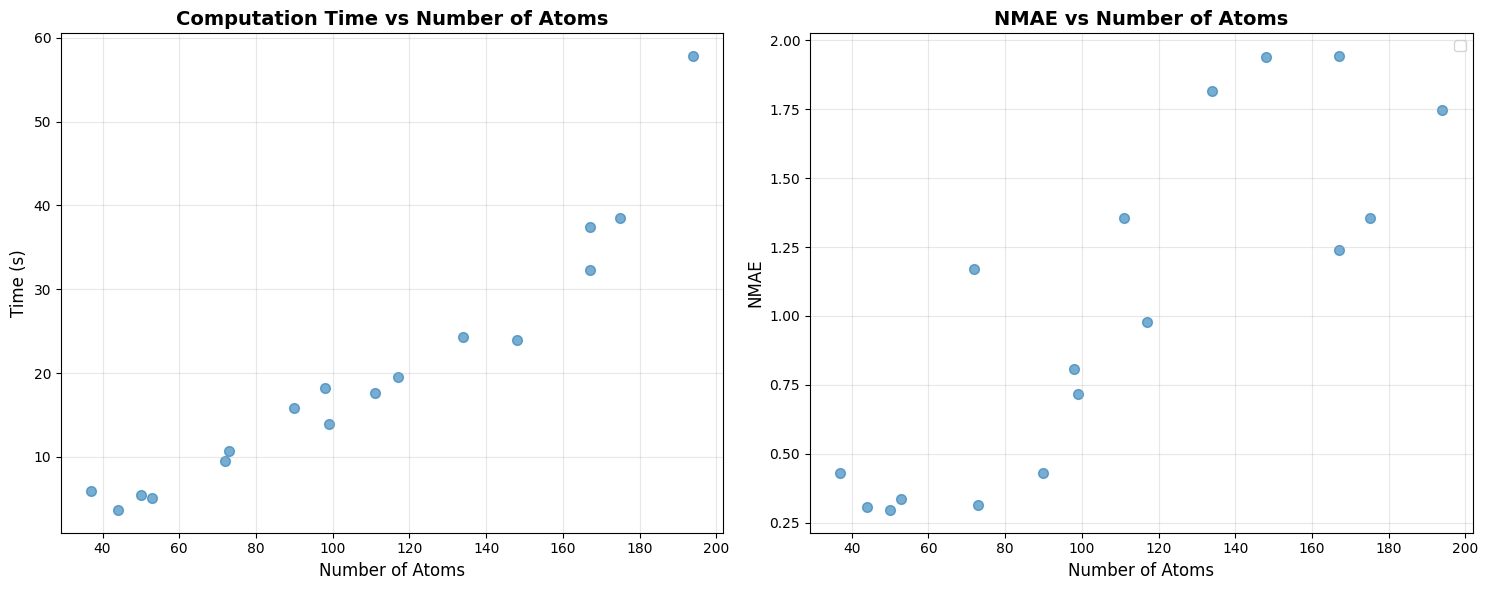


Statistics:
Time:
  Mean: 19.9887 s
  Median: 17.5854 s
  Min: 3.6707 s
  Max: 57.8280 s

NMAE:
  Mean: 1.010914
  Median: 0.979136
  Min: 0.296258
  Max: 1.942760

Number of Atoms:
  Mean: 107.6
  Median: 99.0
  Min: 37
  Max: 194


In [41]:
import matplotlib.pyplot as plt

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time vs num_atoms
ax = axes[0]
ax.scatter(df['num_atoms'], df['time'], alpha=0.6, s=50)
# ax.scatter(df['num_atoms'], df_resnet['time'], alpha=0.6, s=50, label='ResNet', color='orange')
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Computation Time vs Number of Atoms', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
# ax.set_yscale('log')

# # Add trend line
# z = np.polyfit(df['num_atoms'], df['time'], 1)
# p = np.poly1d(z)
# ax.plot(df['num_atoms'].sort_values(), p(df['num_atoms'].sort_values()), 
#         "r--", alpha=0.8, label=f'Linear fit: y={z[0]:.2f}x+{z[1]:.2f}')
# ax.legend()

# Plot 2: NMAPE vs num_atoms
ax = axes[1]
ax.scatter(df['num_atoms'], df['nmape'], alpha=0.6, s=50)
# ax.scatter(df['num_atoms'], df_resnet['nmape']*100, alpha=0.6, s=50, label='ResNet', color='orange')
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('NMAE', fontsize=12)
ax.set_title('NMAE vs Number of Atoms', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics:")
print(f"Time:")
print(f"  Mean: {df['time'].mean():.4f} s")
print(f"  Median: {df['time'].median():.4f} s")
print(f"  Min: {df['time'].min():.4f} s")
print(f"  Max: {df['time'].max():.4f} s")

print(f"\nNMAE:")
print(f"  Mean: {df['nmape'].mean():.6f}")
print(f"  Median: {df['nmape'].median():.6f}")
print(f"  Min: {df['nmape'].min():.6f}")
print(f"  Max: {df['nmape'].max():.6f}")

print(f"\nNumber of Atoms:")
print(f"  Mean: {df['num_atoms'].mean():.1f}")
print(f"  Median: {df['num_atoms'].median():.1f}")
print(f"  Min: {df['num_atoms'].min()}")
print(f"  Max: {df['num_atoms'].max()}")